# Notebook: 01-02-Basics - Building a Conversational AI System
___
## Overview
This notebook demonstrates the setup and implementation of a conversational AI system using AWS services and MLflow for tracking. The system is designed to handle customer interactions with intelligence and maintain conversation state.



# 1.Initial setup
___
### Essential imports for the conversational AI system
- langgraph: For building conversational flows
- psycopg2: For database interactions
- MLflow: For experiment tracking and monitoring
- boto3: For AWS service interactions

In [1]:
# %%capture --no-stderr
# !pip install -U langgraph
# !pip install psycopg2-binary==2.9.9
# !pip install python-dotenv

In [ ]:
import os
import sys
import boto3
import json
import logging
import mlflow
from mlflow.entities import SpanType


from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from pprint import pprint

In [4]:
mlflow.__version__

'2.20.3'

# Setup Path and Environment
Add backend directory to system path for module imports

In [5]:
# Get the absolute path to the backend directory
current_dir = os.getcwd()  # Get current working directory
backend_path = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(backend_path)

# Load environment variables from .env file
load_dotenv()

True

## Importing Custom libraries

In [6]:
# from backend import tools_config
from backend.tools_config.entry_intent_tool import tool_config as entry_intent_tool_config
from backend.tools_config.agent_tool import tool_config as agent_tool_config
from backend.utils import rds_utils
from backend.utils import utils
from backend.static import static

# 2. MLflow Configuration
___
- Sets up MLflow tracking with AWS SageMaker
- Enables auto-logging for LangChain and/or Bedrock interactions
- Configures MLflow tracking URI using environment variables


In [ ]:
# # Enable auto-tracing for Amazon Bedrock
mlflow.bedrock.autolog()
mlflow.langchain.autolog()

In [8]:
try:
    mlflow_arn = os.getenv('MLFLOW_TRACKING_ARN')
    if mlflow_arn:
        print(f'\nMLFlow tracking URI: {mlflow_arn}')
        mlflow.set_tracking_uri(mlflow_arn)
        print('Successfully connected to MLFlow tracking server')
except Exception as e:
    print('Error connecting to MLFlow tracking server')
    raise e


MLFlow tracking URI: arn:aws:sagemaker:us-west-2:577201992296:mlflow-tracking-server/bedrock-chatbot-mlflow
Successfully connected to MLFlow tracking server


# 3. State Management
___
```python
# Defines the conversation state structure using TypedDict
class State(TypedDict):
    messages: list            # Stores conversation messages
    transcript: list          # Maintains conversation history
    session_id: str           # Unique session identifier
    order_number: str         # Tracks order references
    session_end: bool         # Flags if conversation is complete
    conversational_turn: int  # Tracks conversation turns
    next_node: str            # Manages conversation flow
    order_confirmed: bool     # Tracks order confirmation status
    order_info_found: bool    # Tracks if order information was found
```

In [9]:
class State(TypedDict):
    messages: list
    transcript: list
    session_id: str
    order_number: str
    session_end: bool
    conversational_turn: int
    next_node: str
    order_confirmed: bool
    order_info_found: bool


# 4. Nodes Configuration
___
Every node is designed to handle a seto of specific activities and interactions with the user, focused on order-related queries and customer support.  
The implementation emphasizes tracking, monitoring, and maintaining conversation state while ensuring a structured flow of interaction.

In [ ]:
@mlflow.trace(span_type=SpanType.AGENT)
def entry_intent(state):
    """
        Entry intent node - This is the initial node of our conversation flow
        It handles the initial user interaction and attempts to find order information
        
        Parameters:
            state (dict): Contains the current conversation state including messages, 
                        transcript, and session information
        Returns:
            state (dict): Updated state with new messages, transcript and next node information
    """

    print('\n <============== Node: entry_intent ===================> \n')

    # Extract key information from the state
    # session_id: unique identifier for this conversation
    # messages: list of all messages exchanged so far
    # transcript: human-readable record of the conversation
    session_id = state.get('session_id')
    messages = state.get('messages', [])
    transcript = state.get('transcript', [])

    # Set up configuration for the AI model call
    # temperature: controls randomness in model responses (lower = more focused)
    # maxTokens: maximum length of the response
    # top_k: number of top tokens to consider for response generation
    inference_config = {
        "temperature": static.TEMPERATURE, 
        "maxTokens": static.MAX_TOKENS
    }
    additional_model_fields = {
        "top_k": static.TOP_K
    }
    request_metadata = {
        'string': 'string'
    }

    # Make initial call to the AI model to process user's message
    # This uses a greeting-specific system prompt to guide the model's response
    response, message, stop_reason = utils.process_message(
        messages=messages,
        model_id=os.getenv('MODELID_CHAT'),
        formatted_system_prompt=static.SYSTEM_PROMPT_GREETING.format(persona=static.PERSONA),
        tool_config=entry_intent_tool_config,
        inference_config=inference_config,
        additional_model_fields=additional_model_fields,
        request_metadata=request_metadata
    )

    # Extract and store the model's response in the conversation transcript and update the sate
    content = response['output']['message']['content'][0]
    response_text = content.get('text', content.get('toolUse', {}).get('input', ''))
    transcript.append({'assistant': response_text})
    state['transcript'] = transcript
    messages.append(message)
    state['messages'] = messages

    # Initialize flag to track if we find order information during the conversation
    order_info_found = False 

    # Tool Use Loop: Handles cases where the model wants to use tools
    # This continues until the model completes its task or no longer needs tools
    while stop_reason == "tool_use":
        # Execute the tool requested by the model
        tool_response = utils.use_tool(messages)
        if tool_response:
            messages.append(tool_response)
            # Parse tool response to look for order information
            try:
                tool_result = json.loads(tool_response['content'][0]['toolResult']['content'][0]['text'])
                # Handle both single items and lists of results
                if isinstance(tool_result, list):
                    tool_result = tool_result[0]
                # If we find a valid order ID, update the state
                if tool_result and isinstance(tool_result, dict) and tool_result.get('id'):
                    state['order_number'] = tool_result.get('id')
                    order_info_found = True
                    state['order_info_found'] = order_info_found
            except (json.JSONDecodeError, KeyError, IndexError) as e:
                logging.error(f"Error processing tool response: {e}")

        # Continue the conversation with the model, now using an order-focused prompt
        response, message, stop_reason = utils.process_message(
            messages=messages,
            model_id=os.getenv('MODELID_CHAT'),
            formatted_system_prompt=static.SYSTEM_PROMPT_FETCH_ORDER.format(persona=static.PERSONA, transcript=transcript),
            tool_config=entry_intent_tool_config,
            inference_config=inference_config,
            additional_model_fields=additional_model_fields,
            request_metadata=request_metadata
        )

        # Update conversation transcript with the new response and update state
        content = response['output']['message']['content'][0]
        response_text = content.get('text', content.get('toolUse', {}).get('input', ''))
        transcript.append({'assistant': response_text})
        state['transcript'] = transcript
        messages.append(message)
        state['messages'] = messages

    # Determine the next step in the conversation flow
    # If we found order info, move to confirmation
    # If not, end the conversation
    if order_info_found:
        state['next_node'] = 'order_confirmation'
    else:
        state['next_node'] = END

    return state


In [ ]:
@mlflow.trace(span_type=SpanType.AGENT)
def order_confirmation(state):
    """
    Order Confirmation Node - Handles the verification and confirmation of order details
    This node processes order information and gets user confirmation
    
    Parameters:
        state (dict): Current conversation state containing messages, transcript,
                     and session information
    Returns:
        state (dict): Updated state with confirmation status and next node information
    """

    print('\n <=============== Node: order_confirmation =============> \n')

    # Extract key information from the state
    # session_id: unique identifier for this conversation
    # messages: complete message history
    # transcript: human-readable conversation record
    session_id = state.get('session_id')
    messages = state.get('messages', [])
    transcript = state.get('transcript', [])

    # Configure AI model parameters
    # temperature: controls response randomness
    # maxTokens: maximum response length
    # top_k: number of tokens to consider
    inference_config = {"temperature": static.TEMPERATURE, "maxTokens": static.MAX_TOKENS}
    additional_model_fields = {"top_k": static.TOP_K}
    request_metadata = {'string': 'string'}

    # Initialize order tracking variables
    # These will store the order details and confirmation status
    order_number = None
    is_confirmed = False

    # Create a clean message history by removing the last assistant message if present
    # This helps prevent repetitive or conflicting responses
    temp_messages = messages[:-1] if messages and messages[-1]['role'] == 'assistant' else messages.copy()

    # First AI interaction: Parse the order details
    # This call focuses on extracting and understanding order information
    response, message, stop_reason = utils.process_message(
        messages=temp_messages,
        model_id=os.getenv('MODELID_CHAT'),
        formatted_system_prompt=static.SYSTEM_PROMPT_PARSE_ORDER.format(persona=static.PERSONA, transcript=transcript),
        tool_config=agent_tool_config,
        inference_config=inference_config,
        additional_model_fields=additional_model_fields,
        request_metadata=request_metadata
    )

    # Process the model's response to extract order details
    # Look for specific tool use that handles order confirmation
    for content in response['output']['message']['content']:
        if content.get('toolUse') and content['toolUse']['name'] == "get_order_and_confirmation":
             # Extract order ID and confirmation status
            order_number = content['toolUse']['input']['order_id']
            is_confirmed = content['toolUse']['input']['is_confirmed']
            
            # Update state with order information
            state['order_number'] = order_number
            state['order_confirmed'] = is_confirmed
            messages.append(message)
            tool_response = utils.use_tool(messages)

            # Execute any necessary tools and store their responses
            if tool_response:
                messages.append(tool_response)
            break

    # Prepare messages for confirmation interaction
    # Remove last assistant message to avoid confusion
    temp_messages = messages[:-1] if messages and messages[-1]['role'] == 'assistant' else messages.copy()

    # Second AI interaction: Handle order confirmation
    # This generates appropriate confirmation messages for the user
    response, message, stop_reason = utils.process_message(
        messages=temp_messages,
        model_id=os.getenv('MODELID_CHAT'),
        formatted_system_prompt=static.SYSTEM_PROMPT_CONFIRM_ORDER.format(persona=static.PERSONA, order_number=order_number),
        tool_config=agent_tool_config,
        inference_config=inference_config,
        additional_model_fields=additional_model_fields,
        request_metadata=request_metadata
    )

    # Update conversation state with confirmation response
    if response and 'output' in response and 'message' in response['output']:
        content = response['output']['message']['content'][0]
        messages.append(message)
        state['messages'] = messages

        # Update transcript with confirmation message
        # Filter out any system messages and keep only user-facing content
        if 'text' in content and stop_reason != "tool_use":
            # Keep only non-reply messages and add the new reply
            transcript = [msg for msg in transcript if msg.get('assistant') is None or 
                         (isinstance(msg.get('assistant'), dict) and 'key' in msg['assistant'])]
            transcript.append({'assistant': content['text']})
            state['transcript'] = transcript

    # Finalize state updates
    state['order_number'] = order_number
    # Determine next step based on confirmation status
    # If confirmed, proceed to resolution; if not, end conversation
    state['next_node'] = 'resolution' if is_confirmed else END

    return state
    

In [ ]:
@mlflow.trace(span_type=SpanType.AGENT)
def resolution(state):
    """
    Resolution Node - Final conversation node that handles the conclusion of the interaction
    This node processes final responses, executes any remaining tools, and determines
    when to end the conversation
    
    Parameters:
        state (dict): Current conversation state containing messages, transcript,
                     and session information
    Returns:
        state (dict): Final state with updated messages and session end status
    """

    print('\n <=============== Node: resolution =====================> \n')

    # Extract key conversation state elements
    # session_id: unique identifier for this conversation
    # messages: complete message history
    # transcript: human-readable conversation record
    session_id = state.get('session_id')
    messages = state.get('messages', [])
    transcript = state.get('transcript', [])

    # Configure AI model parameters for final interactions
    # temperature: controls response randomness
    # maxTokens: maximum response length
    # top_k: number of tokens to consider
    inference_config = {"temperature": static.TEMPERATURE, "maxTokens": static.MAX_TOKENS}
    additional_model_fields = {"top_k": static.TOP_K}
    request_metadata = {'string': 'string'}

    # Create clean message history by removing last assistant message
    # This prevents repetitive responses and ensures fresh context
    temp_messages = messages[:-1] if messages and messages[-1]['role'] == 'assistant' else messages.copy()

    # Initial resolution message processing
    # Uses a resolution-specific system prompt to guide the conversation closure
    response, message, stop_reason = utils.process_message(
        messages=temp_messages,
        model_id=os.getenv('MODELID_CHAT'),
        formatted_system_prompt=static.SYSTEM_PROMPT_RESOLUTION.format(persona=static.PERSONA, transcript=transcript), 
        tool_config=agent_tool_config,
        inference_config=inference_config,
        additional_model_fields=additional_model_fields,
        request_metadata=request_metadata
    )
    
    # Safely handle and store model's response
    # Only adds new messages if they're unique and valid
    if response and 'output' in response and 'message' in response['output']:
        content = response['output']['message']['content'][0]
        if 'text' in content:
            new_message = {'assistant': content['text']}
             # Avoid duplicate messages in transcript
            if not transcript or transcript[-1] != new_message:
                transcript.append(new_message)
                state['transcript'] = transcript
                messages.append(message)
                state['messages'] = messages

    # Tool Use Loop: Handle any final tool executions
    # Continues until all necessary tools are executed
    while stop_reason == "tool_use":
        tool_response = utils.use_tool(messages)
        if tool_response:
            messages.append(tool_response)
            state['messages'] = messages
            
            # Get final response after tool execution
            # Ensures smooth conversation flow after tool use
            temp_messages = messages.copy()
            response, message, stop_reason = utils.process_message(
                messages=temp_messages,
                model_id=os.getenv('MODELID_CHAT'),
                formatted_system_prompt=static.SYSTEM_PROMPT_RESOLUTION.format(persona=static.PERSONA, transcript=transcript),
                tool_config=agent_tool_config,
                inference_config=inference_config,
                additional_model_fields=additional_model_fields,
                request_metadata=request_metadata
            )
            
            # Update conversation record with new responses
            if response and 'output' in response and 'message' in response['output']:
                content = response['output']['message']['content'][0]
                if 'text' in content:
                    transcript.append({'assistant': content['text']})
                    state['transcript'] = transcript
                    messages.append(message)
                    state['messages'] = messages

    
    # Check for conversation end signals
    # Analyzes last user message for farewell indicators
    last_user_message = ""
    for msg in reversed(messages):
        if msg['role'] == 'user':
            content = msg['content'][0]
            if 'text' in content:
                last_user_message = content['text'].lower()
                break
    
    # List of phrases that indicate user wants to end conversation
    farewell_phrases = ["that's all thanks", "i'm all set", "bye", "goodbye", "thank you", "thanks"]
    
    # Set session end flag if farewell detected
    if any(phrase in last_user_message for phrase in farewell_phrases):
        state['session_end'] = True
    
    # Mark this as the final node in the conversation flow
    state['next_node'] = END

    return state
    

# 5. Graph Setup

In [ ]:
# Define the conversation flow graph structure
# StateGraph manages the flow between different conversation nodes
graph_builder = StateGraph(State)

# Add all conversation nodes to the graph
# Each node represents a different stage of the conversation
graph_builder.add_node("entry_intent", entry_intent)           # Initial interaction node
graph_builder.add_node("order_confirmation", order_confirmation) # Order verification node
graph_builder.add_node("resolution", resolution)               # Conversation closure node

# Initial router function - Determines the starting point of conversation
# Based on the current state, directs to appropriate node
def initial_router(state):
    """
    Initial routing logic that determines the first node to execute
    based on the conversation state
    
    Parameters:
        state (dict): Current conversation state
    Returns:
        str: Name of the next node to execute
    """
    if state.get('order_confirmed'):
        state['next_node'] = 'resolution'          # If order is confirmed, go to resolution
    elif state.get('order_info_found'):
        state['next_node'] = 'order_confirmation'  # If order found but not confirmed, go to confirmation
    else:
        state['next_node'] = 'entry_intent'        # Start fresh conversation
    return state['next_node']

# General router function - Handles transitions between nodes
def router(state):
    """
    General routing logic for node transitions
    
    Parameters:
        state (dict): Current conversation state
    Returns:
        str: Name of the next node to execute
    """
    if state.get('order_confirmed'):
        return 'resolution'                        # Priority route to resolution if order confirmed
    return state.get('next_node')                  # Otherwise follow state's next_node

# Configure graph edges and routing logic
# These define how the conversation can flow between nodes

# Set up initial routing from START
# Maps initial state to appropriate starting nodes
graph_builder.add_conditional_edges(
    START,
    initial_router,
    {
        'entry_intent': 'entry_intent',             # Route to initial interaction
        'order_confirmation': 'order_confirmation', # Route to order confirmation
        'resolution': 'resolution'                  # Route to conversation closure
    }
)

# Configure transitions from entry_intent node
# Defines where conversation can go after initial interaction
graph_builder.add_conditional_edges(
    'entry_intent',
    lambda x: x["next_node"],
    {
        'order_confirmation': 'order_confirmation', # Move to order confirmation
        '__end__': END                              # Or end conversation
    }
)

# Configure transitions from order_confirmation node
# Defines possible paths after order confirmation attempt
graph_builder.add_conditional_edges(
    'order_confirmation',
    lambda x: x["next_node"],
    {
        'resolution': 'resolution',               # Move to resolution phase
        '__end__': END                            # Or end conversation
    }
)

# Add final edge from resolution to END
# Resolution always leads to conversation end
graph_builder.add_edge('resolution', END)

# Compile the graph to make it executable
# This creates the final conversation flow structure
graph = graph_builder.compile()

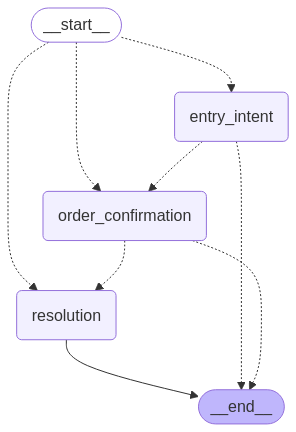

In [14]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

# 6. Testing
___ 

In [15]:
import uuid
session_id = str(uuid.uuid4())

In [16]:
session_id

'e5bee83b-a6f2-4533-89aa-2542af68b156'

In [17]:
mlflow.set_experiment(str(session_id))
mlflow.tracing.enable_notebook_display()

2025/03/25 17:30:53 INFO mlflow.tracking.fluent: Experiment with name 'e5bee83b-a6f2-4533-89aa-2542af68b156' does not exist. Creating a new experiment.


In [18]:
messages = 'I need help with an order'
# messages = 'I need help with an order.My order umber is 24601'
# messages = "I need help with an order. I don't remember my order id. My email is john@example.com"

In [ ]:
# Initialize the conversation state dictionary
# This holds all necessary information about the current conversation
state = {
    # Unique identifier for this conversation session
    'session_id': session_id,
    
    # Message history in format required by the AI model
    # Initializes with the first user message
    'messages': [{
        "role": "user",
        "content": [{"text": messages}]
    }],
    
    # Human-readable conversation history
    # Starts empty and builds throughout conversation
    'transcript': [],
    
    # Flag to track if conversation should end
    # False by default, set to True when conversation concludes
    'session_end': False,
    
    # Counter for conversation turns
    # Starts at 1 for first interaction
    'current_turn': 1,
    
    # Tracks which node should process next
    # Initially None until routing logic determines first node
    'next_node': None,
    
    # Order processing flags and data
    'order_confirmed': False,    # Tracks if order is verified
    'order_number': None,        # Stores order ID when found
    'order_info_found': False,   # Tracks if order info was located
}

# Add initial user message to the transcript
# This creates the first entry in the conversation history
state['transcript'].append({'user': messages})

In [20]:
# Store the initial state
initial_state = state.copy()
pprint(initial_state)

{'current_turn': 1,
 'messages': [{'content': [{'text': 'I need help with an order'}],
               'role': 'user'}],
 'next_node': None,
 'order_confirmed': False,
 'order_info_found': False,
 'order_number': None,
 'session_end': False,
 'session_id': 'e5bee83b-a6f2-4533-89aa-2542af68b156',
 'transcript': [{'user': 'I need help with an order'}]}


## First Interaction

In [ ]:
# Execute the conversation flow graph with current state
# This processes the user's input through all necessary nodes
graph.invoke(state)

# Merge the graph execution results with initial state
# This combines the original state with any updates from the conversation
returned_state = graph.invoke(state)
state = {**initial_state, **returned_state}

# Print the last message in the conversation transcript
# This shows the final response or outcome of the interaction
pprint(state['transcript'][-1])


 <============== Node: entry_intent ===================> 

{'assistant': "<reply>Hello! I'd be happy to help you with your order. To "
              "assist you better, I'll need either:\n"
              '1. Your order ID number, or\n'
              '2. Your email, phone number, or username associated with your '
              'account\n'
              '\n'
              'Could you please provide any of these details?</reply>'}


## Second Inetraction

In [ ]:
# Process new user message about order inquiry
new_message = 'I need help with an order.My order number is 24601'

# Update conversation turn counter
# Keeps track of back-and-forth exchanges
state['current_turn'] += 1

# Add new user message to the AI model's message history
# Formatted in the structure expected by the model
state['messages'].append({
    "role": "user",
    "content": [{"text": new_message}]
})

# Add user message to human-readable transcript
# This maintains a clean conversation history
state['transcript'].append({'user': new_message}) 

# Create backup of current state before processing
# This preserves original context for state merging
initial_state = state.copy()

# Process the new message through conversation flow graph
# This will route through appropriate nodes based on order inquiry
returned_state = graph.invoke(state)

# Merge original state with processed results
# Ensures no context is lost while adding new information
state = {**initial_state, **returned_state}

# Display the last message in transcript
# Shows AI's response to the order inquiry
pprint(state['transcript'][-1])


 <============== Node: entry_intent ===================> 


 <=============== Node: order_confirmation =============> 

{'assistant': "<reply>I see you're inquiring about Order #24601. Could you "
              "please confirm if this is the order you'd like me to look up "
              'for you?</reply>'}


## Third Interaction

In [23]:
new_message = "Perfect! that's the order"
state['current_turn'] += 1  # Increment turn counter
state['messages'].append({
    "role": "user",
    "content": [{"text": new_message}]
})
state['transcript'].append({'user': new_message})
initial_state = state.copy()
# pprint(initial_state)
returned_state = graph.invoke(state)
state = {**initial_state, **returned_state}
pprint(state['transcript'][-1])


 <=============== Node: order_confirmation =============> 


 <=============== Node: resolution =====================> 

{'assistant': '<thinking>\n'
              'Now that the order is confirmed, I should ask the user what '
              'specific help they need with the order. Based on the available '
              'tools, I can help with:\n'
              "1. Canceling the order (if it's still processing)\n"
              "2. Updating the order (if it's still processing)\n"
              '</thinking>\n'
              '\n'
              '<reply>Thank you for confirming! How can I help you with Order '
              '#24601? I can assist you with:\n'
              "1. Making updates to the order (if it's still processing)\n"
              "2. Canceling the order (if it's still processing)\n"
              '\n'
              "Please let me know what you'd like to do.</reply>"}


## Fourth Interaction

In [24]:
new_message = "I want to cancel the order"
state['current_turn'] += 1  # Increment turn counter
state['messages'].append({
    "role": "user",
    "content": [{"text": new_message}]
})
state['transcript'].append({'user': new_message})
initial_state = state.copy()
returned_state = graph.invoke(state)
state = {**initial_state, **returned_state}
pprint(state['transcript'][-1])


 <=============== Node: resolution =====================> 


 ------- CANCEL ORDER: 24601 ---------- 


 ------- QUERY: UPDATE orders SET status = 'Cancelled' WHERE id = %s AND status = 'Processing' ----------- 

Cancel successful: Mockup function not real implementation
{'assistant': "<reply>I've successfully cancelled your order #24601. You "
              'should receive a confirmation email shortly. Is there anything '
              'else I can help you with?</reply>'}


## Fifth Interaction

In [25]:
new_message = "I'm all set. Thank you"
state['current_turn'] += 1  # Increment turn counter
state['messages'].append({
    "role": "user",
    "content": [{"text": new_message}]
})
state['transcript'].append({'user': new_message})
initial_state = state.copy()
returned_state = graph.invoke(state)
state = {**initial_state, **returned_state}
pprint(state['transcript'][-1])


 <=============== Node: resolution =====================> 

{'assistant': '<thinking>\n'
              "The user has indicated they don't need any further assistance "
              'and has expressed gratitude. I should provide a polite closing '
              'response.\n'
              '</thinking>\n'
              '\n'
              "<reply>You're welcome! Thank you for choosing AnyCompany. Have "
              'a great day!</reply>'}
